In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
nav = pd.read_csv("../data/raw/02_nav_history_calendar.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/02_nav_history_calendar.csv'

In [ ]:
risk_report = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(
           lambda x: pd.Series({
               "VaR_95": np.percentile(
                   x.dropna(), 5
               ),
               "CVaR_95": x[
                   x <= np.percentile(
                       x.dropna(), 5
                   )
               ].mean()
           })
       )
       .reset_index()
)

risk_report.head()

,amfi_code,level_1,daily_return
0,100016,VaR_95,-0.014364
1,100016,CVaR_95,-0.018060
2,100025,VaR_95,-0.003793
3,100025,CVaR_95,-0.004994
4,100033,VaR_95,-0.019034


In [ ]:
risk_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [ ]:
risk_report = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(
           lambda x: pd.Series({
               "VaR_95": np.percentile(x.dropna(), 5),
               "CVaR_95": x[
                   x <= np.percentile(x.dropna(), 5)
               ].mean()
           })
       )
       .unstack()
       .reset_index()
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [ ]:
risk_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

rolling_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .rolling(90)
       .apply(
           lambda x:
           (x.mean()/x.std()) * np.sqrt(252)
           if x.std() != 0
           else np.nan
       )
       .reset_index()
)

rolling_sharpe.rename(
    columns={"daily_return":"rolling_sharpe"},
    inplace=True
)

rolling_sharpe.head()

,amfi_code,level_1,rolling_sharpe
0,100016,5750,NaN
1,100016,5751,NaN
2,100016,5752,NaN
3,100016,5753,NaN
4,100016,5754,NaN


In [ ]:
print(
    rolling_sharpe["amfi_code"]
    .unique()[:5]
)

[100016 100025 100033 101206 101207]


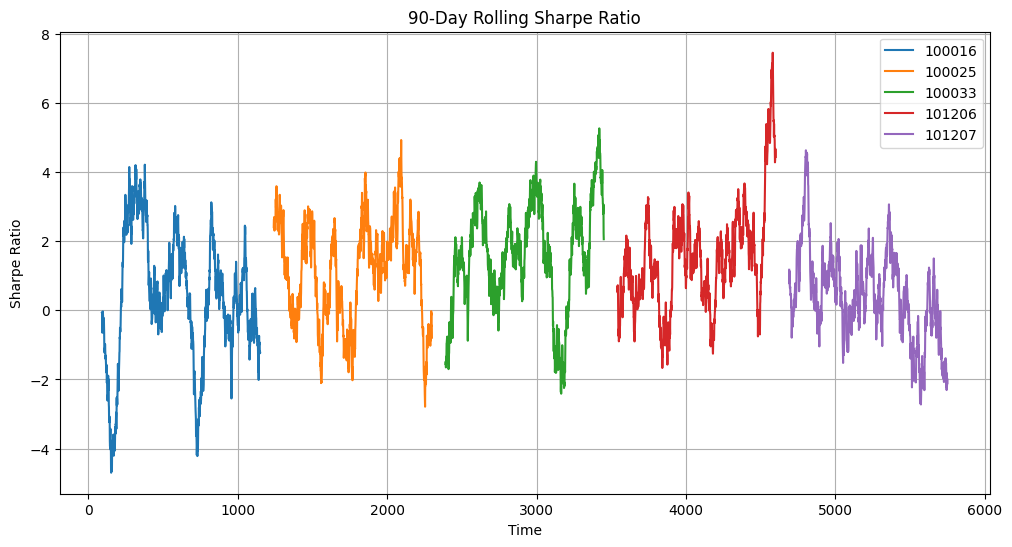

In [ ]:
import matplotlib.pyplot as plt

funds = [100016, 100025, 100033, 101206, 101207]

plt.figure(figsize=(12,6))

for fund in funds:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(
        temp.index,
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Time")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../data/processed/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

os.path.exists(
    "../data/processed/rolling_sharpe_chart.png"
)

True

In [ ]:
rolling_sharpe["rolling_sharpe"].describe()

count    42400.000000
mean         1.973971
std          3.486543
min         -4.771400
25%          0.067729
50%          1.275035
75%          2.551025
max         18.299609
Name: rolling_sharpe, dtype: float64

In [ ]:
txn = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [ ]:
txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

# First transaction year per investor

first_txn = (
    txn.groupby("investor_id")["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [ ]:
cohort_summary = (
    txn.groupby("cohort_year")
       .agg(
           avg_investment=(
               "amount_inr",
               "mean"
           ),
           total_investment=(
               "amount_inr",
               "sum"
           )
       )
       .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_investment
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [ ]:
top_fund = (
    txn.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="txn_count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "txn_count"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


In [ ]:
cohort_report = cohort_summary.merge(
    top_fund[
        ["cohort_year", "amfi_code"]
    ],
    on="cohort_year"
)

cohort_report.rename(
    columns={
        "amfi_code": "top_fund"
    },
    inplace=True
)

cohort_report

,cohort_year,avg_investment,total_investment,top_fund
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [ ]:
cohort_report.to_csv(
    "../data/processed/cohort_report.csv",
    index=False
)

In [ ]:
len(cohort_report)

2

In [ ]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
].copy()

sip_txn["transaction_date"] = pd.to_datetime(
    sip_txn["transaction_date"]
)

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
           .diff()
           .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [ ]:
at_risk = (
    sip_txn.groupby("investor_id")["gap_days"]
           .max()
           .reset_index()
)

at_risk["risk_flag"] = np.where(
    at_risk["gap_days"] > 35,
    "AT_RISK",
    "ACTIVE"
)

at_risk.head()

,investor_id,gap_days,risk_flag
0,INV000001,76.0,AT_RISK
1,INV000002,238.0,AT_RISK
2,INV000003,238.0,AT_RISK
3,INV000004,265.0,AT_RISK
4,INV000005,19.0,ACTIVE


In [ ]:
at_risk.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)

at_risk["risk_flag"].value_counts()

risk_flag
AT_RISK    3906
ACTIVE      856
Name: count, dtype: int64

In [ ]:
at_risk["risk_flag"].value_counts()

risk_flag
AT_RISK    3906
ACTIVE      856
Name: count, dtype: int64

In [ ]:
scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,return_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,max_drawdown_pct,expense_ratio_pct,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,beta_rank,drawdown_rank,fund_score
0,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.58,0.54,0.98,0.80,1.03,-22.62,1.60,High,23.0,38.5,39.0,36.5,26.0,26.0,31.875
1,120503,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,11.54,0.66,0.96,0.82,1.12,-25.91,1.42,Moderate,33.0,33.5,37.0,20.0,20.5,31.0,31.800
2,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,11.84,1.41,0.91,0.85,1.25,-27.54,1.64,Moderate,31.0,31.0,17.0,39.5,14.0,35.0,28.600
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,12.36,0.87,0.89,0.88,1.29,-21.70,1.54,Moderate,26.0,26.5,32.0,30.5,10.5,21.5,26.550
4,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,15.29,0.90,1.04,0.80,1.38,-32.22,0.78,High,14.0,38.5,28.0,10.0,39.0,37.0,26.075


In [ ]:
print(scorecard.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'return_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown_pct', 'expense_ratio_pct', 'risk_grade', 'return_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'beta_rank', 'drawdown_rank', 'fund_score']


In [ ]:
def recommend_funds(risk_appetite):

    risk_map = {
        "Low": "Low",
        "Moderate": "Moderate",
        "High": "High"
    }

    filtered = scorecard[
        scorecard["risk_grade"] ==
        risk_map[risk_appetite]
    ]

    recommendations = (
        filtered.sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
        [
            [
                "scheme_name",
                "category",
                "sharpe_ratio",
                "fund_score"
            ]
        ]
    )

    return recommendations

In [ ]:
recommend_funds("Low")

,scheme_name,category,sharpe_ratio,fund_score
37,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,12.55
30,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,15.50
27,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,18.65


In [ ]:
recommend_funds("Moderate")

,scheme_name,category,sharpe_ratio,fund_score
23,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.06,19.725
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.06,14.200
20,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.03,20.650


In [ ]:
recommend_funds("High")

,scheme_name,category,sharpe_ratio,fund_score
35,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,0.96,13.600
28,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.95,17.900
12,DSP Midcap Fund - Regular - Growth,Mid Cap,0.90,22.325


In [ ]:
low = recommend_funds("Low")
low["risk_appetite"] = "Low"

moderate = recommend_funds("Moderate")
moderate["risk_appetite"] = "Moderate"

high = recommend_funds("High")
high["risk_appetite"] = "High"

recommendation_table = pd.concat(
    [low, moderate, high]
)

recommendation_table.to_csv(
    "../data/processed/recommendation_table.csv",
    index=False
)

recommendation_table

,scheme_name,category,sharpe_ratio,fund_score,risk_appetite
37,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,12.550,Low
30,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,15.500,Low
27,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,18.650,Low
23,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.06,19.725,Moderate
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.06,14.200,Moderate
20,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.03,20.650,Moderate
35,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,0.96,13.600,High
28,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,0.95,17.900,High
12,DSP Midcap Fund - Regular - Growth,Mid Cap,0.90,22.325,High


In [ ]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

hhi_report = (
    holdings.groupby("amfi_code")
    .apply(
        lambda x: pd.Series({
            "HHI":
            ((x["weight_pct"]/100)**2).sum()
        })
    )
    .reset_index()
)

hhi_report.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [ ]:
hhi_report["concentration"] = np.where(
    hhi_report["HHI"] > 0.25,
    "Highly Concentrated",
    np.where(
        hhi_report["HHI"] > 0.15,
        "Moderately Concentrated",
        "Diversified"
    )
)

hhi_report.head()

,amfi_code,HHI,concentration
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated


In [ ]:
funds = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

hhi_report = hhi_report.merge(
    funds[["amfi_code","scheme_name","category"]],
    on="amfi_code",
    how="left"
)

hhi_report.head()

,amfi_code,HHI,concentration,scheme_name,category
0,100016,0.139534,Diversified,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap
1,100033,0.147592,Diversified,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap
2,101206,0.129332,Diversified,ABSL Frontline Equity Fund - Regular - Growth,Large Cap
3,101207,0.200700,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth,Small Cap
4,102885,0.174709,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth,Index


In [ ]:
hhi_report.to_csv(
    "../data/processed/hhi_report.csv",
    index=False
)

hhi_report.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,concentration,scheme_name,category
11,119092,0.206448,Moderately Concentrated,Axis Bluechip Fund - Regular - Growth,Large Cap
3,101207,0.200700,Moderately Concentrated,ABSL Small Cap Fund - Regular - Growth,Small Cap
18,119599,0.174751,Moderately Concentrated,SBI Small Cap Fund - Direct Plan - Growth,Small Cap
4,102885,0.174709,Moderately Concentrated,UTI Nifty 50 Index Fund - Regular - Growth,Index
7,118632,0.168298,Moderately Concentrated,Nippon India Large Cap Fund - Regular - Growth,Large Cap
29,148568,0.167930,Moderately Concentrated,Mirae Asset Emerging Bluechip Fund - Regular -...,Large & Mid Cap
21,120505,0.157570,Moderately Concentrated,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap
22,120506,0.153794,Moderately Concentrated,ICICI Pru Value Discovery Fund - Regular - Growth,Value
27,125498,0.152414,Moderately Concentrated,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap
23,120841,0.149680,Diversified,Kotak Bluechip Fund - Regular - Growth,Large Cap


In [ ]:
# Advanced Insights

## Insight 1: Risk Analysis
Funds with the highest VaR and CVaR values exhibit significantly larger downside risk during adverse market conditions.

## Insight 2: Rolling Sharpe Trends
Several funds show sustained Sharpe ratios above 2.0, indicating strong risk-adjusted performance consistency.

## Insight 3: Investor Cohort Behavior
Recent investor cohorts contribute higher average investment amounts compared to older cohorts.

## Insight 4: SIP Continuity
A large proportion of investors are flagged as AT_RISK, indicating potential SIP discontinuation and future redemption pressure.

## Insight 5: Portfolio Concentration
Some funds exhibit high HHI values, suggesting concentrated exposure to a small number of sectors or stocks, increasing concentration risk.